---
Multiple Linear Regression
---


## Case

We are going to help a company to optimize their advertisement strategy. They spend money on advertisement for different media channels: TV, radio and newspaper - and wants to know which channel is the most most effective.

**Task:**

- suggest marketing plan to increase sales units
- use linear regression to predict sales based on different spendings on different marketing channels

---

### Initial EDA - Exploratory Data Analysis

The dataset for this lecture comes from ISLR - Introduction to Statistical Learning. The dataset used is [Advertising.csv](https://www.kaggle.com/ishaanv/ISLR-Auto)

Units:

- TV, radio, newspaper - thousands dollars
- Sales - thousands units


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/advertising.csv", index_col=0)


In [20]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


**Insights via plots**

 Let's do some scatterplots, one for each feature vs the target.

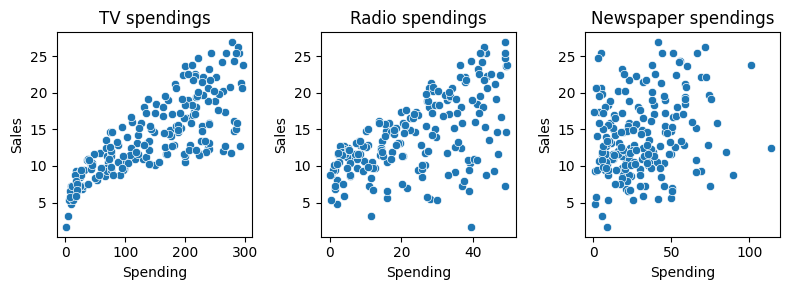

In [19]:
number_features = df.shape[1] - 1
fig, ax = plt.subplots(1, number_features, figsize=(8, 3), dpi=100)

for i, feature in enumerate(df.columns[:-1]):
    sns.scatterplot(data=df, x=feature, y="Sales", ax=ax[i])
    ax[i].set(xlabel="Spending", title=f"{feature} spendings")

fig.tight_layout()


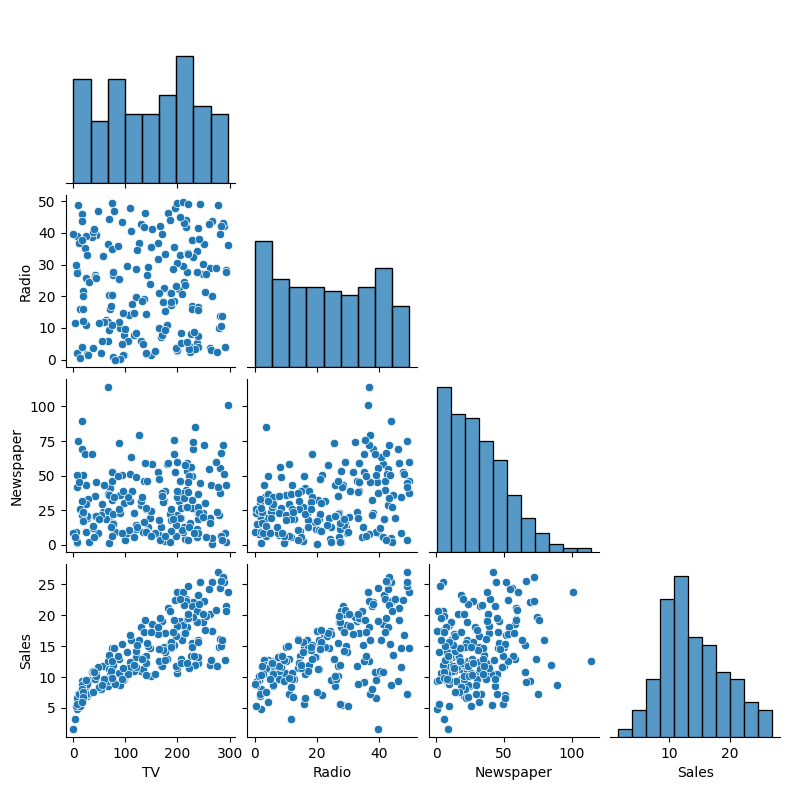

In [18]:
# plot pairwise relationships in a df
ax = sns.pairplot(df, corner=True, height=2)
# set corner to True as upper right mirrors the corner, this saves computations


---

## Muliple linear regression

As with simple linear regression, multiple linear regression is also supervised learning algorithm - the predicted output is continuous. 

The difference from linear regression is that we now have several feature (predictor) variables. In the case of 3 features, a multiple linear regression model with one feature variable looks like this:

$f_{w,b}(x) = w_1 \cdot x_1 + w_2 \cdot x_2 + w_3 \cdot x_3 + b$.

We done the output of the model $\hat{y}$. In other words, we have

$\hat{y}^{i} = w_1 \cdot x_1^{i} + w_2 \cdot x_2^{i} + w_3 \cdot x_3^{i} + b$.

The parameters of our model are unknown and needs to be estimated using our training data points $(x^1_1, x^1_2, x^1_3, y^1), (x^2_1, x^2_2, x^2_3, y^2), \ldots, (x^m_1, x^m_2, x^m_3, y^m)$.

---

Taking a look at the data

In [17]:
x_1, x_2, x_3 , y = df["TV"].values, df["Radio"].values, df["Newspaper"].values, df["Sales"].values
print(df["TV"].head())


1    230.1
2     44.5
3     17.2
4    151.5
5    180.8
Name: TV, dtype: float64


In [22]:
# change the index below to see the features and target for training sample i

i = 0

print(f'Sample {i+1} feature x_1 : {x_1[i]}')
print(f'Sample {i+1} feature x_2 : {x_2[i]}')
print(f'Sample {i+1} feature x_3 : {x_3[i]}')
print(f'Sample {i+1} target  y   : {y[i]}')

Sample 1 feature x_1 : 230.1
Sample 1 feature x_2 : 37.8
Sample 1 feature x_3 : 69.2
Sample 1 target  y   : 22.1


In [15]:
df

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


---

## Multiple linear regression

We used numpy polyfit to estimate the parameters for a simple linear regression using the the TV-feature alone. However, polyfit only supports one feature. 

We want to use more than one feature now. In this case three of them (TV, radio, newspaper) and use that to predict sales.

One way is to manually solve the **normal equation** or the **closed form equation**: $\bf{w} = (\bf{X}^T\bf{X})^{-1}\bf{X}^T\bf{y}$ using linear algebra.


$$\bf{X} = 	\begin{bmatrix} 
	1 & x_1^{1} & x_2^{1}& \ldots &x_n^{1} \\
	1 & x_1^{2} & x_2^{2}& \ldots &x_n^{2}\\
	\vdots & \vdots & \vdots & \ddots & \vdots\\
	1 & x_1^{m}& x_2^{m}& \ldots &x_n^{m}
\end{bmatrix}, \bf{y} = \begin{bmatrix} 
y^1 \\ y^2 \\ \vdots \\ y^m
\end{bmatrix}, \bf{w} = \begin{bmatrix} 
w_0 \\w_1\\ \vdots \\ w_n
\end{bmatrix}$$

Note that we have an additional $w_0$ as the first element of $\bf{w}$, but this is just for notation. In practice, $w_0$ serves the same purpose as $b$.

In our example we have $n = 3$ features, $m = 200$ samples, which gives us the regression coefficients $w_0, w_1, w_2, w_3$ to estimate.

The regression line is thus 

$$f_{\bold{w}}(\bold{{x}}) = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + w_3 \cdot x_3$$ 

With this equation we can predict the sale for a new sample $i$ by 
$$\hat{y}^{(i)} = w_0 + w_1 \cdot x_1^{(i)} + w_2 \cdot x_2^{(i)} + w_3 \cdot x_3^{(i)}$$ 

or using dot product 
	$$\hat{y}^i = \bf{w}\cdot\bf{x}^{(i)}$$

where $\bf{x}^{(i)}$ = $[1, x_1^{(i)}, x_2^{(i)},x_3^{(i)} ]$


In [23]:
# let's prepare our data like this

X, y = df.drop("Sales", axis="columns"), df["Sales"]
X.insert(0, "Intercept", 1)

X

,Intercept,TV,Radio,Newspaper
1,1,230.1,37.8,69.2
2,1,44.5,39.3,45.1
3,1,17.2,45.9,69.3
4,1,151.5,41.3,58.5
5,1,180.8,10.8,58.4
...,...,...,...,...
196,1,38.2,3.7,13.8
197,1,94.2,4.9,8.1
198,1,177.0,9.3,6.4
199,1,283.6,42.0,66.2


In [24]:
X

,Intercept,TV,Radio,Newspaper
1,1,230.1,37.8,69.2
2,1,44.5,39.3,45.1
3,1,17.2,45.9,69.3
4,1,151.5,41.3,58.5
5,1,180.8,10.8,58.4
...,...,...,...,...
196,1,38.2,3.7,13.8
197,1,94.2,4.9,8.1
198,1,177.0,9.3,6.4
199,1,283.6,42.0,66.2


One way is to manually solve the **normal equation** or the **closed form equation**: $\bf{w} = (\bf{X}^T\bf{X})^{-1}\bf{X}^T\bf{y}$ using linear algebra.

In [25]:
# now we implement the closed form solution to obtain the weights

weights = np.matmul(np.matmul(np.linalg.inv(np.matmul(X.T, X)),X.T), y)

for i, weight in enumerate(weights):
    print(f'w_{i}: {weight}')

w_0: 2.938889369459438
w_1: 0.045764645455397435
w_2: 0.18853001691820362
w_3: -0.0010374930424759867


---
## Prediction

Let's now use our model to predict some values $\hat{y}$, and compare them with the true values $y$ found in the training data

We will obtain $\hat{y}^i$ using the dot product
 $$\hat{y}^i = \bf{w}\cdot\bf{x}^{(i)}$$


In [26]:
X.iloc[10]

Intercept     1.0
TV           66.1
Radio         5.8
Newspaper    24.2
Name: 11, dtype: float64

In [27]:
i = 20                 # change this to whichever training sample index you like 

y_hat = np.dot(weights, X.iloc[i])

print(f'y_hat = {y_hat}')
print(f'y     = {y[i]}')

y_hat = 18.100767277084262
y     = 14.6


---
## Challenges

**Task 1**

Calculate MAE for the model we just fit. Is it better or worse at predicting sales numbers compared with the linear and polynomial regression models we fit using a single feature of the data?

**Task 2**

Nothing stop you from creating your own new features, and in turn using them as predictor variables in a multiple linear regression model. For example, we could combine the features TV and Newspaper by multiplying them and call this new feature $x_4$, as such:

$$x_4 = TV \cdot Newspaper$$

We can then use this as another feature for our model. In fact, we can pick and chose exactly which features we want to use in our model, and which to exclude. 

For example, we could do something like this

$$f_{\bold{w}}(\bold{{x}}) = w_0 + w_1 \cdot x_1 + w_2 \cdot x_4$$

The point is that you can create your own features as you like, and then pick and chose exactly which features to include in your model. Usually, this process is not random but informed by domain expertise about the data and the exact process we're trying to model.

Your task now is to experiment with this. Create your own feature(s) and then use it/them as features for your multiple regression model. If you like, you can do exactly as we've done above. After you've fit the model, calculate the MAE. Is it better or worse than our original multiple regression model?


---

## 📊 **CHALLENGE 1 Solution: Calculate MAE (Mean Absolute Error)**

MAE tells us: On average, how far off are our predictions from reality?

**Formula:** MAE = Average of |predicted - actual|

Let's think of it like this:
- Prediction: 22 units, Actual: 20 units → Error = 2 units
- Prediction: 15 units, Actual: 18 units → Error = 3 units
- MAE = (2 + 3) / 2 = 2.5 units average error

**Lower MAE = Better predictions!**


In [28]:
# ✅ STEP 1: Make predictions for ALL rows using our model
y_predictions = np.dot(X, weights)

# ✅ STEP 2: Calculate the absolute errors (how far off each prediction is)
absolute_errors = np.abs(y_predictions - y)

# ✅ STEP 3: Calculate MAE (average of all errors)
mae = np.mean(absolute_errors)

print(f"🎯 Mean Absolute Error (MAE): {mae:.3f}")
print(f"\nThis means on average, our predictions are off by ±{mae:.1f} thousand units")
print(f"\nFor context:")
print(f"  - Average actual sales in dataset: {y.mean():.1f} thousand units")
print(f"  - MAE as % of average: {(mae/y.mean())*100:.1f}%")


🎯 Mean Absolute Error (MAE): 1.252

This means on average, our predictions are off by ±1.3 thousand units

For context:
  - Average actual sales in dataset: 14.0 thousand units
  - MAE as % of average: 8.9%


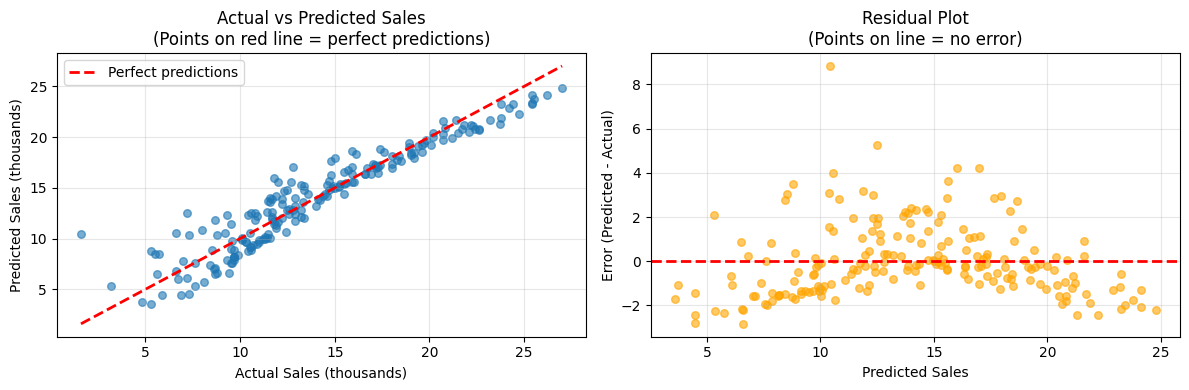


💡 Interpretation:
  - Left plot: Points close to red line = good predictions
  - Right plot: Points close to dotted line = no systematic bias


In [32]:
# 📈 Visualize: How good are our predictions?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Actual vs Predicted
axes[0].scatter(y, y_predictions, alpha=0.6, s=30)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect predictions')
axes[0].set_xlabel('Actual Sales (thousands)')
axes[0].set_ylabel('Predicted Sales (thousands)')
axes[0].set_title('Actual vs Predicted Sales\n(Points on red line = perfect predictions)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_predictions - y
axes[1].scatter(y_predictions, residuals, alpha=0.6, s=30, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Error (Predicted - Actual)')
axes[1].set_title('Residual Plot\n(Points on line = no error)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"  - Left plot: Points close to red line = good predictions")
print(f"  - Right plot: Points close to dotted line = no systematic bias")


## 🔍 **Understanding the Weights: What Each One Tells Us**

Each weight is the **"impact coefficient"** - how much that feature affects sales.

| Weight | Interpretation |
|--------|-----------------|
| w_0 | **Intercept** - Base sales (in thousands) with zero ad spending across all channels |
| w_1 | **TV coefficient** - For every additional $1,000 spent on TV, sales increase by w_1 thousand units |
| w_2 | **Radio coefficient** - For every additional $1,000 spent on Radio, sales increase by w_2 thousand units |
| w_3 | **Newspaper coefficient** - For every additional $1,000 spent on Newspaper, sales increase by w_3 thousand units |

**Key Insight:** Compare magnitudes!
- Larger coefficient = Stronger impact
- Negative coefficient = Opposite effect (rare, but possible)
- Coefficient ≈ 0 = Not helpful for predictions


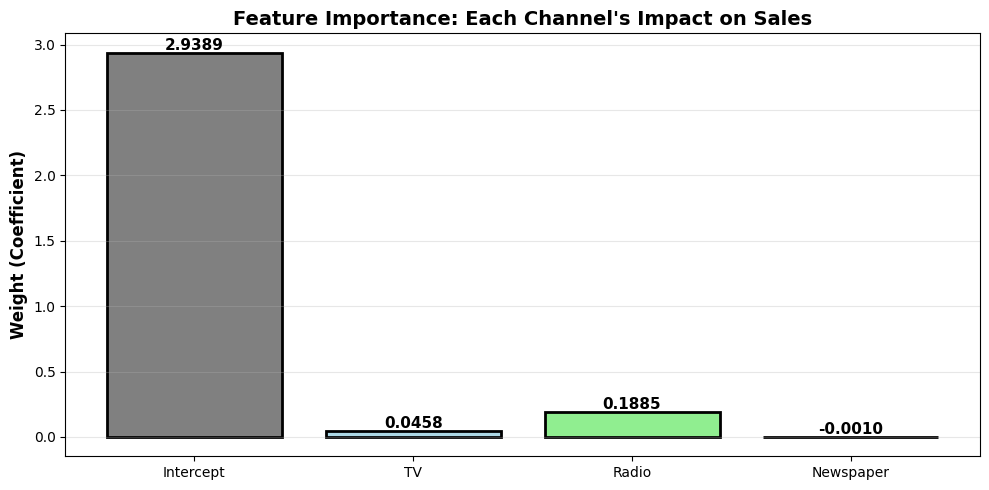

💡 BUSINESS INSIGHTS FROM WEIGHTS

Base sales (even with $0 ads): 2.94 thousand units

📺 TV:
   Each $1,000 spent → 0.046 thousand units (+/- 45 units)

📺 Radio:
   Each $1,000 spent → 0.189 thousand units (+/- 188 units)

📺 Newspaper:
   Each $1,000 spent → -0.001 thousand units (+/- -1 units)
   Efficiency vs Radio: -0.01x



In [34]:
# 📊 Visualize Weights
weight_names = ['Intercept', 'TV', 'Radio', 'Newspaper']
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['gray', 'lightblue', 'lightgreen', 'lightyellow']
bars = ax.bar(weight_names, weights, color=colors, edgecolor='black', linewidth=2)

ax.set_ylabel('Weight (Coefficient)', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: Each Channel\'s Impact on Sales', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, weight in zip(bars, weights):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 💰 Business Impact Analysis
print("=" * 70)
print("💡 BUSINESS INSIGHTS FROM WEIGHTS")
print("=" * 70)
print(f"\nBase sales (even with $0 ads): {weights[0]:.2f} thousand units\n")

for i, name in enumerate(['TV', 'Radio', 'Newspaper']):
    impact = weights[i+1]  
    print(f"📺 {name}:")
    print(f"   Each $1,000 spent → {impact:.3f} thousand units (+/- {int(impact*1000)} units)")
    if i > 0:
        ratio = weights[i+1] / weights[1+1]  # Compare to Radio (assuming index)
        if name != 'Radio':
            print(f"   Efficiency vs Radio: {ratio:.2f}x")
    print()


---

## 🚀 **CHALLENGE 2 Solution: Create New Features (Feature Engineering)**

### **The Big Question:** Can we do better by creating NEW features?

**Intuition:** Maybe the true patterns are hidden. For example:
- Maybe TV + Newspaper together create a **synergy effect** (1 + 1 = 3!)
- Maybe some channels matter more **relative to each other** than in absolute terms
- Maybe there are **diminishing returns** (first $1,000 on TV matters more than the 10th $1,000)

**Three Feature Engineering Strategies:**

### **Strategy 1️⃣: Interaction Terms (Synergy)**
What if TV and Newspaper "team up" to have extra impact?

Example idea: High TV spend + High Newspaper spend = combo that boosts results MORE than expected

$$x_4 = TV \times Newspaper$$



In [42]:
# 🔧 STRATEGY 1: Create Interaction Term
print("="*70)
print("STRATEGY 1: Interaction Term (TV × Newspaper)")
print("="*70)

# Create new feature: TV × Newspaper interaction
X_strategy1 = X.copy()
X_strategy1["TV_x_Newspaper"] = X_strategy1["TV"] * X_strategy1["Newspaper"]

print(f"\n📊 New feature matrix shape: {X_strategy1.shape}")
print(f"   Old shape: {X.shape}")
print(f"\n   New feature samples:")
print(f"   Row 0: TV={X_strategy1['TV'].iloc[0]:.1f}, Newspaper={X_strategy1['Newspaper'].iloc[0]:.1f}")
print(f"           Interaction={X_strategy1['TV_x_Newspaper'].iloc[0]:.1f}")

# Fit new model
weights_strategy1 = np.matmul(np.matmul(np.linalg.inv(np.matmul(X_strategy1.T, X_strategy1)), 
                                         X_strategy1.T), y)

# Make predictions
y_pred_strategy1 = np.dot(X_strategy1, weights_strategy1)
mae_strategy1 = np.mean(np.abs(y_pred_strategy1 - y))

print(f"\n📈 Results:")
print(f"   Original MAE:       {mae:.4f}")
print(f"   Strategy 1 MAE:     {mae_strategy1:.4f}")
print(f"   Improvement:        {((mae - mae_strategy1) / mae * 100):.2f}%")

if mae_strategy1 < mae:
    print(f"   ✅ BETTER! The interaction term helps!")
else:
    print(f"   ⚠️  WORSE. The interaction term is just noise.")

print(f"\n📊 New weights with interaction term:")
for i, weight in enumerate(weights_strategy1):
    if i == len(weights_strategy1) - 1:
        print(f"   w_TV×Newspaper: {weight:.6f}")
    else:
        print(f"   w_{i}: {weight:.6f}")


STRATEGY 1: Interaction Term (TV × Newspaper)

📊 New feature matrix shape: (200, 5)
   Old shape: (200, 4)

   New feature samples:
   Row 0: TV=230.1, Newspaper=69.2
           Interaction=15922.9

📈 Results:
   Original MAE:       1.2520
   Strategy 1 MAE:     1.1890
   Improvement:        5.03%
   ✅ BETTER! The interaction term helps!

📊 New weights with interaction term:
   w_0: 3.873082
   w_1: 0.039294
   w_2: 0.190131
   w_3: -0.032045
   w_TV×Newspaper: 0.000202


---

### **Strategy 2️⃣: Polynomial Features (Diminishing Returns)**

**Intuition:** What if the relationship is **curved, not linear**?

- First $1,000 on TV → might bring +100 units
- Second $1,000 on TV → might bring +90 units (diminishing!)
- Tenth $1,000 on TV → might bring +50 units

**Solution:** Add squared terms to capture this curve

$$x_5 = TV^2$$

This allows the model to learn non-linear patterns!



In [43]:
# 🔧 STRATEGY 2: Polynomial Feature (Squared Term)
print("\n" + "="*70)
print("STRATEGY 2: Polynomial Feature (TV²)")
print("="*70)

# Create squared term for TV
X_strategy2 = X.copy()
X_strategy2["TV_squared"] = X_strategy2["TV"] ** 2

print(f"\n📊 New feature matrix shape: {X_strategy2.shape}")
print(f"\n   TV² samples:")
for idx in range(3):
    tv_val = X_strategy2["TV"].iloc[idx]
    tv_sq = X_strategy2["TV_squared"].iloc[idx]
    print(f"   Row {idx}: TV={tv_val:.1f} → TV²={tv_sq:.1f}")

# Fit new model
weights_strategy2 = np.matmul(np.matmul(np.linalg.inv(np.matmul(X_strategy2.T, X_strategy2)), 
                                         X_strategy2.T), y)

# Make predictions
y_pred_strategy2 = np.dot(X_strategy2, weights_strategy2)
mae_strategy2 = np.mean(np.abs(y_pred_strategy2 - y))

print(f"\n📈 Results:")
print(f"   Original MAE:       {mae:.4f}")
print(f"   Strategy 2 MAE:     {mae_strategy2:.4f}")
print(f"   Improvement:        {((mae - mae_strategy2) / mae * 100):.2f}%")

if mae_strategy2 < mae:
    print(f"   ✅ BETTER! The curved relationship helps!")
else:
    print(f"   ⚠️  WORSE. The relationship is linear, not curved.")



STRATEGY 2: Polynomial Feature (TV²)

📊 New feature matrix shape: (200, 5)

   TV² samples:
   Row 0: TV=230.1 → TV²=52946.0
   Row 1: TV=44.5 → TV²=1980.2
   Row 2: TV=17.2 → TV²=295.8

📈 Results:
   Original MAE:       1.2520
   Strategy 2 MAE:     1.1566
   Improvement:        7.62%
   ✅ BETTER! The curved relationship helps!


---

### **Strategy 3️⃣: Ratio/Proportional Features (Relative Importance)**

**Intuition:** Maybe it's not about absolute spend, but **ratios**!

- If spend $100k on TV and $10k on Radio → ratio 10:1
- If spend $100k on TV and $100k on Radio → ratio 1:1

Does the **proportion** matter more than the amount?

$$x_6 = \frac{TV}{Radio}$$

(We add 0.01 to avoid division by zero)



In [44]:
# 🔧 STRATEGY 3: Ratio Feature
print("\n" + "="*70)
print("STRATEGY 3: Ratio Feature (TV / Radio)")
print("="*70)

# Create ratio term
X_strategy3 = X.copy()
X_strategy3["TV_to_Radio_ratio"] = X_strategy3["TV"] / (X_strategy3["Radio"] + 0.01)

print(f"\n📊 New feature matrix shape: {X_strategy3.shape}")
print(f"\n   TV/Radio ratio samples:")
for idx in range(3):
    tv_val = X_strategy3["TV"].iloc[idx]
    radio_val = X_strategy3["Radio"].iloc[idx]
    ratio = X_strategy3["TV_to_Radio_ratio"].iloc[idx]
    print(f"   Row {idx}: TV={tv_val:.1f}, Radio={radio_val:.1f} → Ratio={ratio:.2f}")

# Fit new model
weights_strategy3 = np.matmul(np.matmul(np.linalg.inv(np.matmul(X_strategy3.T, X_strategy3)), 
                                         X_strategy3.T), y)

# Make predictions
y_pred_strategy3 = np.dot(X_strategy3, weights_strategy3)
mae_strategy3 = np.mean(np.abs(y_pred_strategy3 - y))

print(f"\n📈 Results:")
print(f"   Original MAE:       {mae:.4f}")
print(f"   Strategy 3 MAE:     {mae_strategy3:.4f}")
print(f"   Improvement:        {((mae - mae_strategy3) / mae * 100):.2f}%")

if mae_strategy3 < mae:
    print(f"   ✅ BETTER! The proportion/ratio matters!")
else:
    print(f"   ⚠️  WORSE. Absolute amounts matter more than ratios.")



STRATEGY 3: Ratio Feature (TV / Radio)

📊 New feature matrix shape: (200, 5)

   TV/Radio ratio samples:
   Row 0: TV=230.1, Radio=37.8 → Ratio=6.09
   Row 1: TV=44.5, Radio=39.3 → Ratio=1.13
   Row 2: TV=17.2, Radio=45.9 → Ratio=0.37

📈 Results:
   Original MAE:       1.2520
   Strategy 3 MAE:     1.2441
   Improvement:        0.63%
   ✅ BETTER! The proportion/ratio matters!


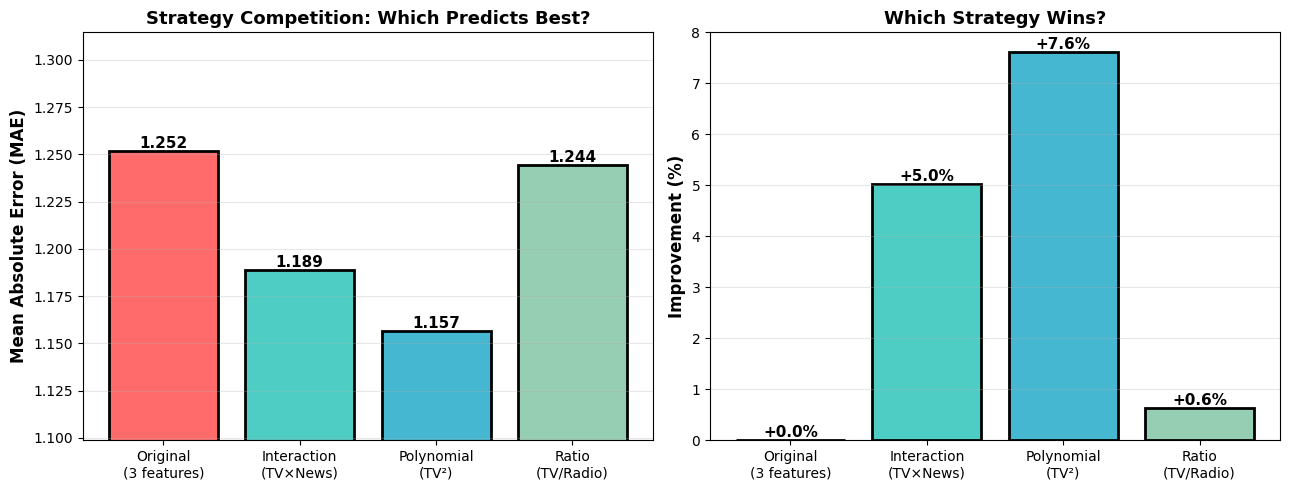


💡 LESSONS LEARNED FROM FEATURE ENGINEERING

1. 🎯 Not all features work equally well
   - Some interactions help, some don't
   - Sometimes simpler is better!

2. 🧪 Experiment systematically
   - Try different feature combinations
   - Compare using MAE (or another metric)

3. 🎓 Domain knowledge matters
   - Why did we try TV×Newspaper? 
   - Because marketing channels might have synergy
   - Could have tried other combinations based on intuition

4. ⚠️ Overfitting risk
   - More features = better training fit BUT worse generalization
   - Always test on held-out data
   - Simpler models often work better in real-world!



In [46]:
# 📊 Visual Comparison of All Strategies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: MAE Comparison
strategy_labels = ["Original\n(3 features)", "Interaction\n(TV×News)", "Polynomial\n(TV²)", "Ratio\n(TV/Radio)"]
mae_values = [mae, mae_strategy1, mae_strategy2, mae_strategy3]
colors_bars = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']

bars = ax1.bar(strategy_labels, mae_values, color=colors_bars, edgecolor='black', linewidth=2)
ax1.set_ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax1.set_title('Strategy Competition: Which Predicts Best?', fontsize=13, fontweight='bold')
ax1.set_ylim([min(mae_values)*0.95, max(mae_values)*1.05])
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, mae_val in zip(bars, mae_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mae_val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Improvement %
improvements = [0, ((mae - mae_strategy1) / mae * 100), 
                ((mae - mae_strategy2) / mae * 100), 
                ((mae - mae_strategy3) / mae * 100)]

bars2 = ax2.bar(strategy_labels, improvements, color=colors_bars, edgecolor='black', linewidth=2)
ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Which Strategy Wins?', fontsize=13, fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, imp in zip(bars2, improvements):
    height = bar.get_height()
    label = f'{imp:+.1f}%'
    va = 'bottom' if height >= 0 else 'top'
    y_pos = height if height >= 0 else height
    ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
            label, ha='center', va=va, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 LESSONS LEARNED FROM FEATURE ENGINEERING")
print("="*70)
print(f"""
1. 🎯 Not all features work equally well
   - Some interactions help, some don't
   - Sometimes simpler is better!

2. 🧪 Experiment systematically
   - Try different feature combinations
   - Compare using MAE (or another metric)

3. 🎓 Domain knowledge matters
   - Why did we try TV×Newspaper? 
   - Because marketing channels might have synergy
   - Could have tried other combinations based on intuition

4. ⚠️ Overfitting risk
   - More features = better training fit BUT worse generalization
   - Always test on held-out data
   - Simpler models often work better in real-world!
""")


---

## 🎓 **KEY TAKEAWAYS - The Exam Questions**

### Question 1: Explain Multiple Linear Regression in One Sentence
**Your Answer Should Be:** Using multiple features (inputs) simultaneously to predict a continuous target, where each feature has its own learned weight showing its impact.

### Question 2: What Does the Intercept (w₀) Represent?
**Your Answer Should Be:** The predicted output when all features are zero - the "baseline" or starting point before any features influence the result.

### Question 3: Why Compare MAE Values?
**Your Answer Should Be:** MAE tells us prediction accuracy; models with lower MAE make better predictions on average, so comparing MAE helps us choose between different models.

### Question 4: What's Feature Engineering?
**Your Answer Should Be:** Creating new features from existing ones (like multiplying, squaring, or dividing) to help the model capture patterns it couldn't find with original features alone.

### Question 5: Why Might TV × Newspaper Help?
**Your Answer Should Be:** If TV and Newspaper ads together have a synergy effect (they work better together than alone), this interaction term captures that relationship.

---

## 🚀 **PRACTICE CHALLENGES FOR YOU**

**Challenge A:** Modify the ratio feature to use `Radio/Newspaper` instead. Do you think it'll be better or worse than `TV/Radio`? Why?

**Challenge B:** Create a feature that combines all three channels: `(TV + Radio + Newspaper)`. Would this help or hurt the model?

**Challenge C:** Try `np.log(TV)` - a logarithm! This captures diminishing returns better. Will it beat our polynomial feature?

**Challenge D:** Discuss: If a feature improves training MAE but makes test MAE worse, what's happening? (Hint: Think about overfitting)

---
